# DAN Implementation Project

In [12]:
%load_ext autoreload
%autoreload 2

import os
import torch
import matplotlib.pyplot as plt
import manage_exp # import first to set cuda tensor type

cuda = torch.cuda.is_available()
device = torch.device('cuda' if cuda else 'cpu')
manage_exp.set_tensor_type('double',cuda)

SEED = 42
torch.manual_seed(SEED)

import filters, lin2d_exp, lorenz_exp
from utils import simulate_sample, plot_trajectories

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
use gpu True
use tensor_type double


In [ ]:
# Download pre-trained checkpoints if not present
import urllib.request, zipfile

REPO = "latestdesign/data_assim_networks"
TAG = "v1.0"
checkpoints_url = f"https://github.com/{REPO}/releases/download/{TAG}/checkpoints.zip"

if not os.path.exists("lin2d_notebook") or not os.path.exists("lorenz_notebook"):
    print("Downloading pre-trained checkpoints...")
    urllib.request.urlretrieve(checkpoints_url, "checkpoints.zip")
    with zipfile.ZipFile("checkpoints.zip", "r") as z:
        z.extractall(".")
    os.remove("checkpoints.zip")
    print("Done.")

## Pre-training for Linear-2D

In [13]:
# Initialization
mb = 128           # Batch size
x_dim = 2          # State vector dimension
m = 2              # Ensemble size
h_dim = x_dim*m    # Hidden dimension of the DAN
sigma0 = 0.01      # std of x0
sigmap = sigma0    # std of prop
sigmao = 10*sigma0 # std of obs

prop = filters.ConstructorProp(**lin2d_exp.k['prop_kwargs'])
obs = filters.ConstructorObs(**lin2d_exp.k['obs_kwargs'])
net = filters.DAN(**lin2d_exp.k['net_kwargs'])

In [18]:
# Pre-training of the DAN
optimizer_classname = lin2d_exp.k["optimizer_classname"]
optimizer_kwargs = lin2d_exp.k['optimizer_kwargs']

manage_exp._x0 = None
manage_exp._v0 = None
net.clear_scores()
manage_exp.pre_train_full(
    net,
    mb,
    h_dim,
    x_dim,
    sigma0,
    optimizer_classname,
    optimizer_kwargs,
)

Pre-train c at t=0
empirical mean of x0 is tensor([2.9985, 2.9995])
## INIT a0 mean tensor([2.9985, 2.9995], grad_fn=<SliceBackward0>)
## INIT a0 var tensor([0.0001, 0.0001], grad_fn=<SliceBackward0>)
## INIT a0 covar tensor([[1.0730e-04, 1.2808e-05],
        [1.2808e-05, 1.0256e-04]], grad_fn=<SliceBackward0>)


## Full-training for Linear-2D

In [19]:
# Full training
RETRAIN = False
T = lin2d_exp.k["train_kwargs"]["T"]
checkpoint = lin2d_exp.k["train_kwargs"]["checkpoint"]
notebook_dir = os.path.join(lin2d_exp.k["directory"],"lin2d_notebook/")
weights_path = os.path.join(notebook_dir, "net_final.pt")

manage_exp._x0 = None

if not RETRAIN and os.path.exists(weights_path):
    print(f"Loading checkpoint from: {weights_path}")
    net.load_state_dict(torch.load(weights_path, map_location=device))
else:
    net.clear_scores()
    manage_exp.train_full(
        net,
        mb,
        h_dim,
        x_dim,
        T,
        checkpoint,
        notebook_dir,
        prop,
        obs,
        sigma0,
        optimizer_classname,
        optimizer_kwargs,
    )
    # Save final weights of the DAN
    torch.save(net.state_dict(), weights_path)

Loading checkpoint from: ./lin2d_notebook/net_final.pt


In [20]:
# Testing
test_T = lin2d_exp.k["test_kwargs"]["T"]
test_checkpoint = lin2d_exp.k["test_kwargs"]["checkpoint"]

torch.manual_seed(SEED) # Set seed for reproducibility of test results
net.clear_scores()
manage_exp.test(
    net,
    mb,
    h_dim,
    x_dim,
    test_T,
    test_checkpoint,
    notebook_dir,
    prop,
    obs,
    sigma0,
)

## Test Cycle 1 ##
RMSE_b= 0.013503767300889844
RMSE_a= 0.05571065662150976
LOGPDF_b= 5.228542432291236
LOGPDF_a= 3.7572720119806
LOSS= -8.985814444271835
## Test Cycle 2 ##
RMSE_b= 0.04205621920739394
RMSE_a= 0.05030732870990109
LOGPDF_b= 3.8912141042789274
LOGPDF_a= 3.7128476648559925
LOSS= -7.60406176913492
## Test Cycle 3 ##
RMSE_b= 0.04887212411565516
RMSE_a= 0.04991072866736568
LOGPDF_b= 3.722987996490226
LOGPDF_a= 3.7296546663126833
LOSS= -7.452642662802909


/home/paul/ModIA/Apprentissage_Physique/TP/projet/src/utils.py:47: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(yt_np[:, 0], yt_np[:, 1], s=22, c=color_obs, marker="x", edgecolors="none", alpha=0.80, label="obs y_t")


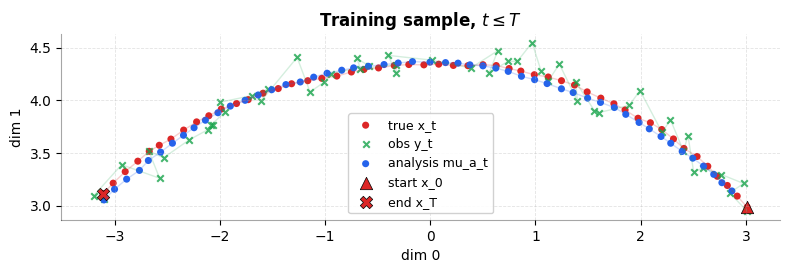

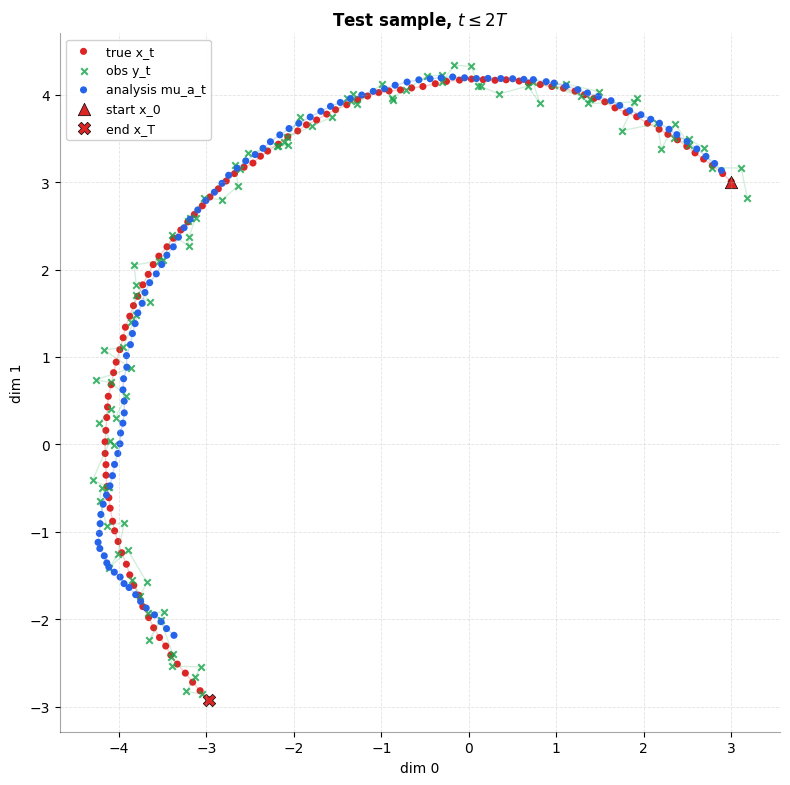

In [21]:
# Plot x_t, y_t and mu_a_t for one training sample, t <= T
x0_train = manage_exp.get_x0(1, x_dim, sigma0)
xt_train, yt_train, mua_train = simulate_sample(net, prop, obs, x0_train, T, h_dim)
plot_trajectories(xt_train, yt_train, mua_train, r"Training sample, $t \leq T$")

# Plot x_t, y_t and mu_a_t for one test sample, t <= 2T
x0_test = manage_exp.get_x0_test(1, x_dim, sigma0)
xt_test, yt_test, mua_test = simulate_sample(net, prop, obs, x0_test, 2 * T, h_dim)
plot_trajectories(xt_test, yt_test, mua_test, r"Test sample, $t \leq 2T$")

## Online-training for Lorentz-40D

In [7]:
# Initialization
x_dim = 40
b_size = 2**10
h_dim = x_dim * 20
sigma0 = 1.0           # std of x0
sigmap = 0.1 * sigma0  # std of prop
sigmao = sigma0        # std of obs

prop = filters.ConstructorProp(**lorenz_exp.k['prop_kwargs'])
obs = filters.ConstructorObs(**lorenz_exp.k['obs_kwargs'])
net = filters.DAN(**lorenz_exp.k['net_kwargs'])

In [8]:
# Online training
RETRAIN = False
T = lorenz_exp.k["train_kwargs"]["T"]
checkpoint = lorenz_exp.k["train_kwargs"]["checkpoint"]
notebook_dir = os.path.join(lorenz_exp.k["directory"], "lorenz_notebook/")
weights_path = os.path.join(notebook_dir, "net.pt")

optimizer_classname = lorenz_exp.k["optimizer_classname"]
optimizer_kwargs = lorenz_exp.k["optimizer_kwargs"]
scheduler_classname = lorenz_exp.k["scheduler_classname"]
scheduler_kwargs = lorenz_exp.k["scheduler_kwargs"]

manage_exp._x0 = None
manage_exp._v0 = None

if not RETRAIN and os.path.exists(weights_path):
    print(f"Loading checkpoint from: {weights_path}")
    net.load_state_dict(torch.load(weights_path, map_location=device))
else:
    net.clear_scores()
    manage_exp.train_online(
        net,
        b_size,
        h_dim,
        x_dim,
        T,
        checkpoint,
        notebook_dir,
        prop,
        obs,
        sigma0,
        optimizer_classname,
        optimizer_kwargs,
        scheduler_classname,
        scheduler_kwargs,
    )

Loading checkpoint from: ./lorenz_notebook/net.pt


In [9]:
# Testing
test_T = lorenz_exp.k["test_kwargs"]["T"]
test_checkpoint = lorenz_exp.k["test_kwargs"]["checkpoint"]

torch.manual_seed(SEED)
net.clear_scores()
manage_exp.test(
    net,
    b_size,
    h_dim,
    x_dim,
    test_T,
    test_checkpoint,
    notebook_dir,
    prop,
    obs,
    sigma0,
)

## Test Cycle 100 ##
RMSE_b= 0.9197615019802657
RMSE_a= 0.6003846238853667
LOGPDF_b= -47.52278884891395
LOGPDF_a= -36.699095050678224
LOSS= 84.22188389959217
## Test Cycle 200 ##
RMSE_b= 0.9206305404741773
RMSE_a= 0.6010463573050435
LOGPDF_b= -48.11142052900688
LOGPDF_a= -36.97308977429588
LOSS= 85.08451030330275
## Test Cycle 300 ##
RMSE_b= 0.9101573618320344
RMSE_a= 0.5980899227469241
LOGPDF_b= -47.29405908634831
LOGPDF_a= -36.364051976013386
LOSS= 83.6581110623617
## Test Cycle 400 ##
RMSE_b= 0.9160984895813709
RMSE_a= 0.6037767503427582
LOGPDF_b= -47.859078196739816
LOGPDF_a= -36.77468019279188
LOSS= 84.63375838953169
## Test Cycle 500 ##
RMSE_b= 0.9098339675814794
RMSE_a= 0.5974205585931172
LOGPDF_b= -47.732303265769275
LOGPDF_a= -36.498798000255576
LOSS= 84.23110126602485
## Test Cycle 600 ##
RMSE_b= 0.9089479044395309
RMSE_a= 0.5961684386128567
LOGPDF_b= -47.48443657827736
LOGPDF_a= -36.57279507434825
LOSS= 84.0572316526256
## Test Cycle 700 ##
RMSE_b= 0.9113440755552276
RMSE_a=

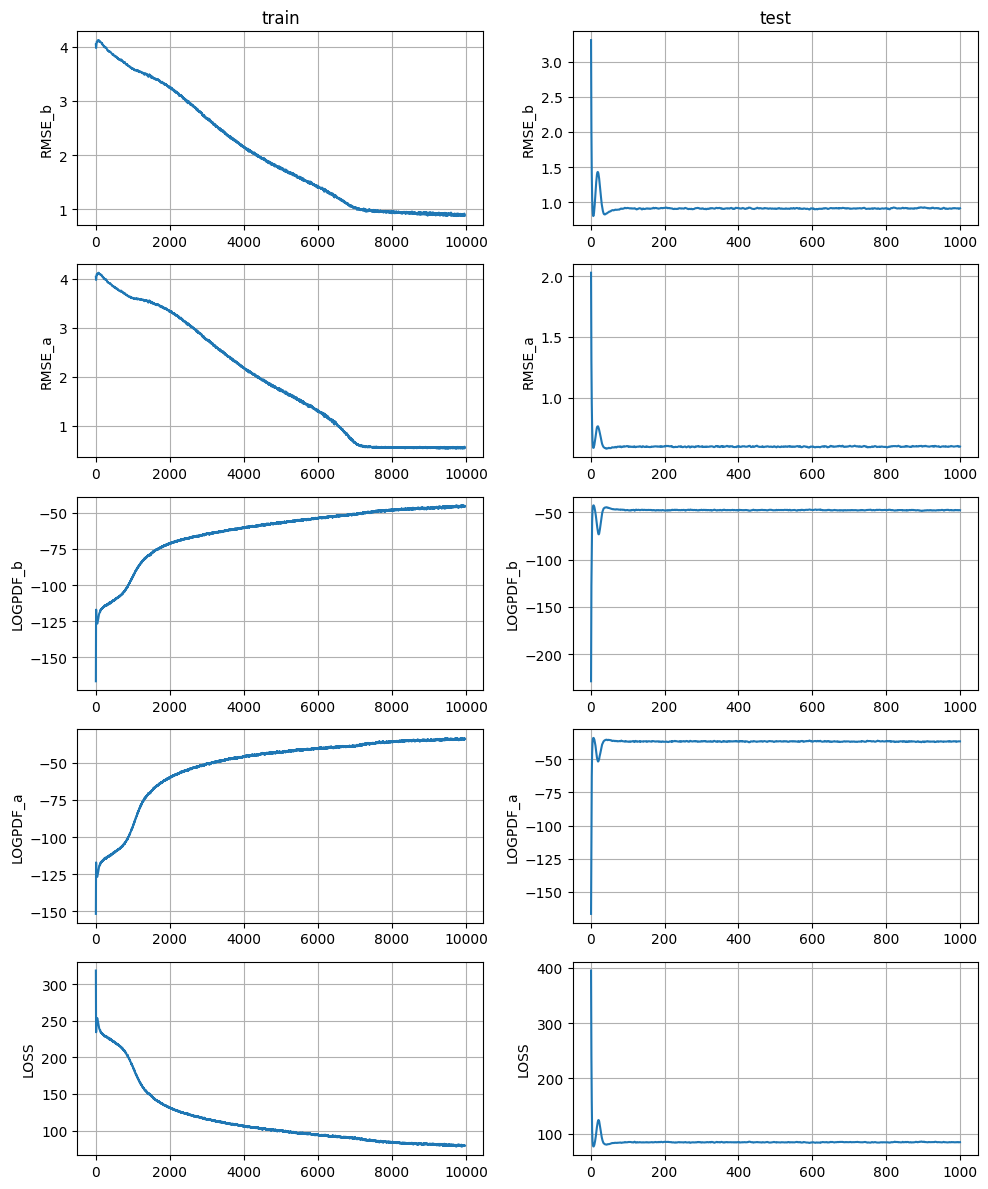

In [10]:
# Plot RMSE scores from training and testing
scores_path = os.path.join(notebook_dir, "scores.pt")
test_scores_path = os.path.join(notebook_dir, "test_scores.pt")

train_scores = torch.load(scores_path, map_location='cpu')
test_scores = torch.load(test_scores_path, map_location='cpu')

kscores = ["RMSE_b", "RMSE_a", "LOGPDF_b", "LOGPDF_a", "LOSS"]

fig, axes = plt.subplots(len(kscores), 2, figsize=(10, 12))
start_ind_train, start_ind_test = 30, 0

for i, kscore in enumerate(kscores):
    for k, (mode, sc) in enumerate([("train", train_scores), ("test", test_scores)]):
        if mode == "train":
            out = sc[kscore][start_ind_train:]
        else:
            out = sc[kscore][start_ind_test:]
        ax = axes[i, k]
        ax.plot(range(1, len(out) + 1), out, label=kscore)
        ax.set_ylabel(kscore)
        ax.grid()
        if i == 0:
            ax.set_title(mode)

plt.tight_layout()
plt.show()
# manage_exp.print_scores(train_scores)
# manage_exp.print_scores(test_scores)

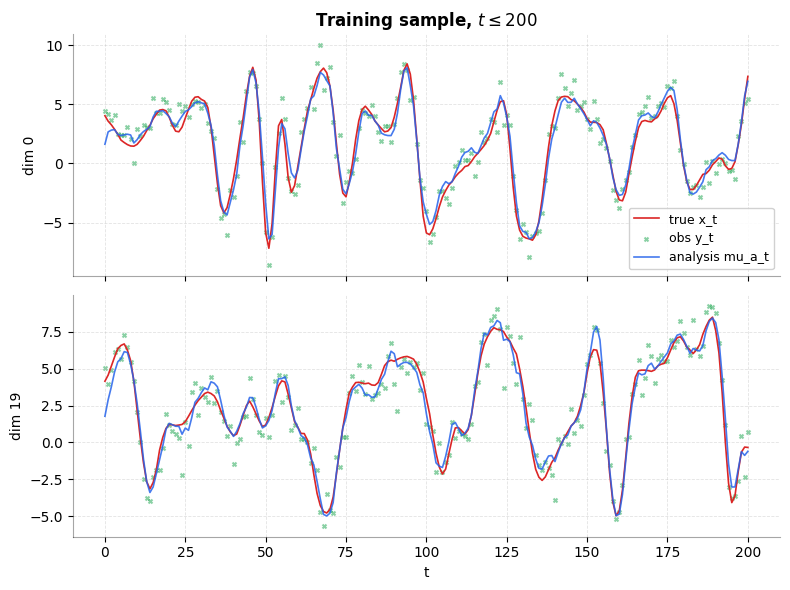

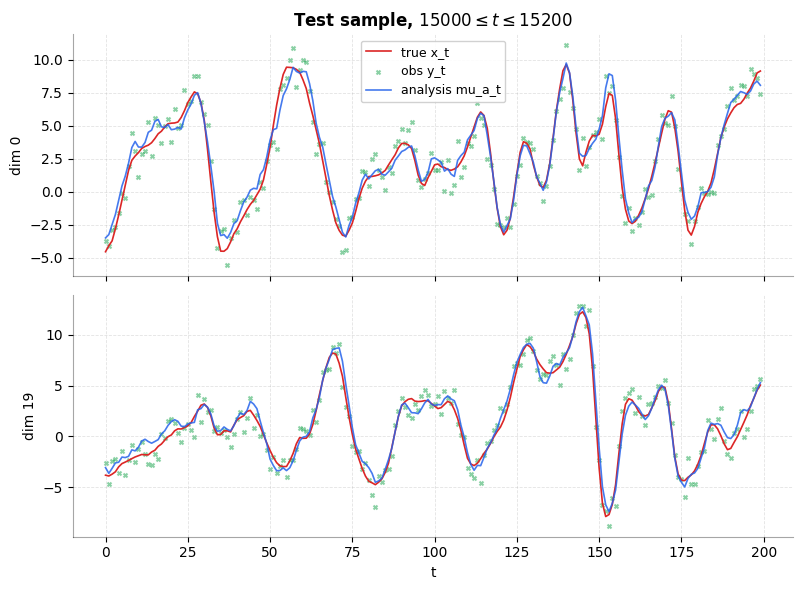

In [11]:
# Plots for Lorenz 40D along selected dimensions
# Plot x_t, y_t and mu_a_t for one training sample, t <= 200
T_sim = 200
torch.manual_seed(SEED)
x0_train = manage_exp.get_x0(1, x_dim, sigma0)
xt_train, yt_train, mua_train = simulate_sample(net, prop, obs, x0_train, T_sim, h_dim)
plot_trajectories(xt_train, yt_train, mua_train, r"Training sample, $t \leq 200$", dims=[0, 19])

# Plot x_t, y_t and mu_a_t for one test sample, 15000 <= t <= 15000 + 200
T_sim = 15000
torch.manual_seed(SEED)
x0_test = manage_exp.get_x0_test(1, x_dim, sigma0)
xt_test, yt_test, mua_test = simulate_sample(net, prop, obs, x0_test, T_sim + 200, h_dim)
plot_trajectories(xt_test[T_sim:T_sim+200], yt_test[T_sim:T_sim+200], mua_test[T_sim:T_sim+200], r"Test sample, $15000 \leq t \leq 15200$", dims=[0, 19])